Comparing Test Scores between Queens and Staten Island

Importing Dataset

In [1]:
# Importing all neccesary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Importing the dataset
df = pd.read_csv("https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv")

In [3]:
# Checking if the data imported correctly
df.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na


In [4]:
# Checking if the data imported correctly
df.describe()

,Year,Total Tested
count,212331.000000,212331.000000
mean,2015.956069,49.364200
std,0.799726,93.023576
min,2015.000000,1.000000
25%,2015.000000,5.000000
50%,2016.000000,20.000000
75%,2017.000000,57.000000
max,2017.000000,1729.000000


In [5]:
#Checking type of values in the Dataset
print(df.dtypes)

School DBN                     object
School Name                    object
School Level                   object
Regents Exam                   object
Year                            int64
Total Tested                    int64
Mean Score                     object
Number Scoring Below 65        object
Percent Scoring Below 65       object
Number Scoring 65 or Above     object
Percent Scoring 65 or Above    object
Number Scoring 80 or Above     object
Percent Scoring 80 or Above    object
Number Scoring CR              object
Percent Scoring CR             object
dtype: object


In [6]:
df.columns

Index(['School DBN', 'School Name', 'School Level', 'Regents Exam', 'Year',
       'Total Tested', 'Mean Score', 'Number Scoring Below 65',
       'Percent Scoring Below 65', 'Number Scoring 65 or Above',
       'Percent Scoring 65 or Above', 'Number Scoring 80 or Above',
       'Percent Scoring 80 or Above', 'Number Scoring CR',
       'Percent Scoring CR'],
      dtype='object')

Cleaning the Dataset

In [7]:
# Cleaning the dataset

# Adding a borough column to make analisys easier. The function (get_borough_name) identifies the borrough from the 3 character of the borough code
def get_borough_name(dbn):
    borough_code = dbn[2]
    if borough_code == 'M':
        return 'Manhattan'
    elif borough_code == 'X':
        return 'Bronx'
    elif borough_code == 'K':
        return 'Brooklyn'
    elif borough_code == 'Q':
        return 'Queens'
    elif borough_code == 'R':
        return 'Staten Island'
    else:
        return 'Unknown'

df['Borough'] = df['School DBN'].apply(get_borough_name) #Calling the function
df.head() # Verifying the creation of the new column

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR,Borough
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na,Manhattan
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na,Manhattan
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na,Manhattan
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na,Manhattan
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na,Manhattan


In [8]:
# Cleaning the data. Droping the school with missing values
print("Original datas in dataframe " + str(len(df)))
df['Mean Score'] = pd.to_numeric(df['Mean Score'], errors='coerce') #errors='coerce' to prevent pd.to_numeric to crash if no numeric value is found
df_clean = df.dropna(subset=['Mean Score'])
print("Clean datas in dataframe " + str(len(df_clean))) #print to check all missing info were deleted


Original datas in dataframe 212331
Clean datas in dataframe 137109


In [9]:
# Creating my filtered subset containing Queens and Staten Island

df_filtered = df_clean[(df_clean['Borough'] == 'Queens') | (df_clean['Borough'] == 'Staten Island')].copy()

print("Out of the " + str(len(df_clean)) + " cleaned data, " + str(len(df_filtered))+ " are from Queens or Staten Island" )
#print(df_filtered.to_string())

Out of the 137109 cleaned data, 32500 are from Queens or Staten Island


Analazing Data

In [10]:
# Analizing Data

# Getting the mean score of Queens and Staten Island

q_mean = df_filtered[df_filtered['Borough'] == 'Queens']['Mean Score'].mean().round(2)
si_mean = df_filtered[df_filtered['Borough'] == 'Staten Island']['Mean Score'].mean().round(2)

print("The mean score of Queens is " + str(q_mean))
print("The mean score of Staten Island is " + str(si_mean))

The mean score of Queens is 68.97
The mean score of Staten Island is 69.1


In [11]:
# Comparing all values, other than mean, for Queens and SI

print(df_filtered.groupby('Borough')['Mean Score'].describe().round(2))

                 count   mean    std   min   25%   50%   75%   max
Borough                                                           
Queens         27848.0  68.97  11.25  24.3  61.3  68.7  76.8  97.6
Staten Island   4652.0  69.10  11.53  29.3  60.8  67.9  77.4  97.0


Data Visualization

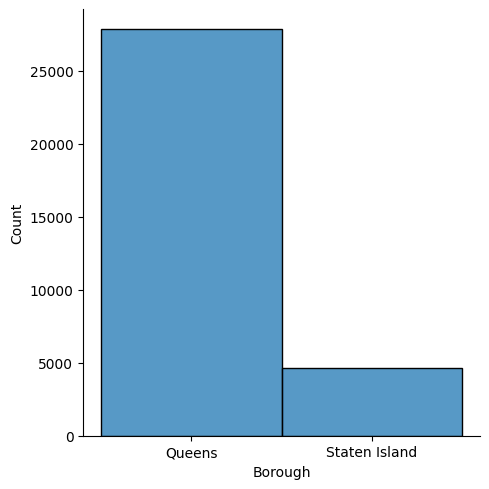

In [13]:
# Vizualizing Data, showing the number of results by borough
sns.displot(df_filtered['Borough'])

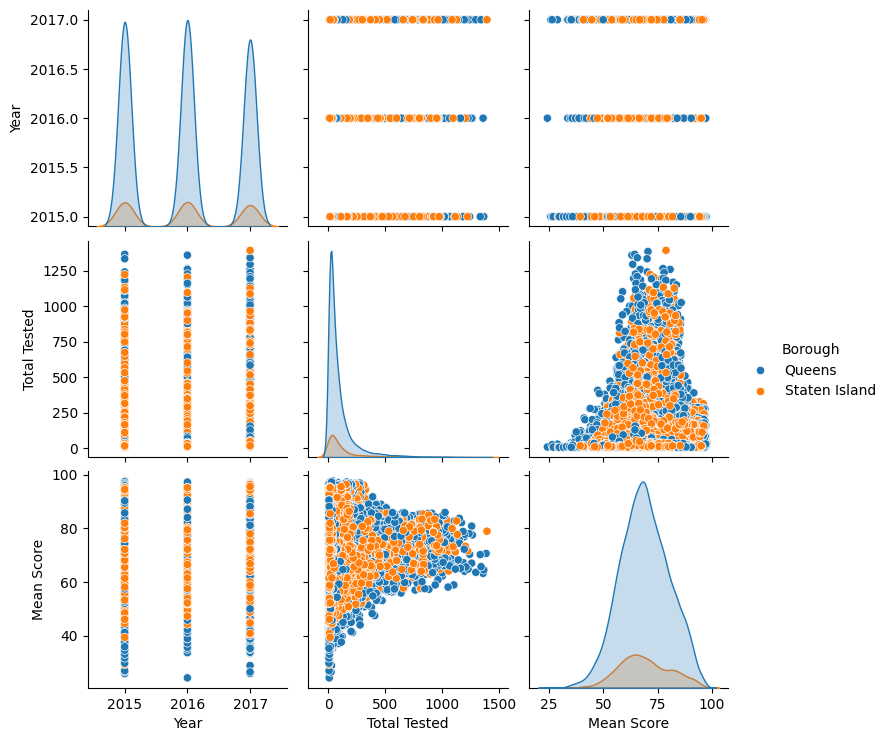

In [14]:
#Another Visualization
sns.pairplot(df_filtered,hue='Borough')

<Axes: xlabel='Borough', ylabel='Mean Score'>

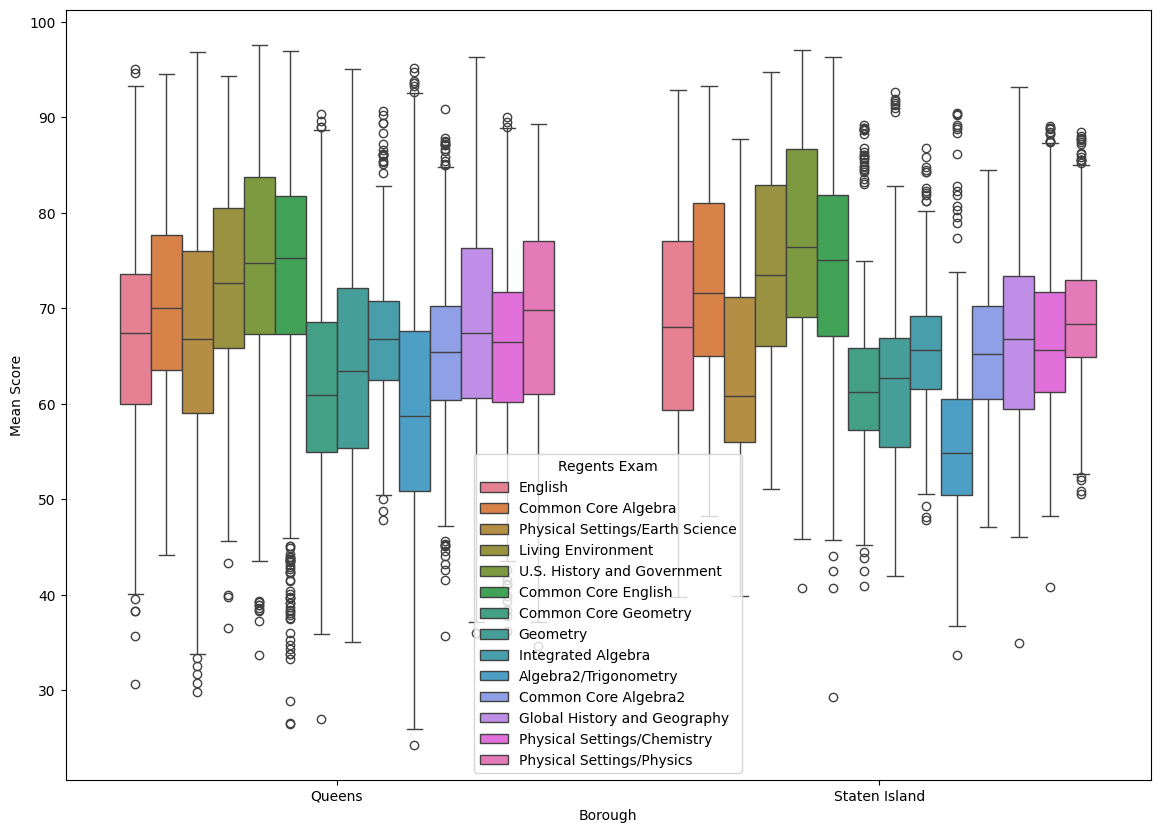

In [15]:
#Now the Boxplot to compare the mean and median of each exam by borough
plt.figure(figsize=(14,10)) #Since there is a lot of exams, figure size needs to be resized
sns.boxplot(x='Borough',y='Mean Score',data=df_filtered,hue='Regents Exam')


<Axes: xlabel='Borough', ylabel='Mean Score'>

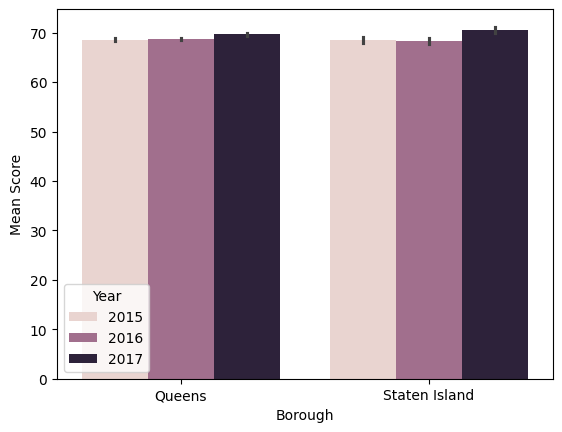

In [16]:
# Barplot to show the mean score of each year
sns.barplot(x='Borough',y='Mean Score',data=df_filtered,hue='Year')

Conclusions:
After analysising and compared the regents exam mean scores for the schools in Queens vs Staten Island across the 2014 to 2017 school years. Staten Island schools tend to have a slightly higher median mean score but a smaller population than Queens, which shows greater variability. Both boroughs display consistent performance trends across the three school years, with no dramatic shifts over time.